# Notebook 2 — Pipeline clásico con scikit-learn

Este notebook construye el baseline clásico del proyecto **Credit Card Churn Scoring** usando:

- `ColumnTransformer` para preprocesamiento integrado
- `Pipeline` de scikit-learn
- comparación de **3 modelos**
- `StratifiedKFold` + `cross_validate`
- tuning del mejor modelo con `RandomizedSearchCV`
- evaluación final con métricas de clasificación
- serialización con `joblib.dump()`

> **Contexto del proyecto**  
> El objetivo es predecir churn (`Attrition_Flag`) a partir de variables demográficas, de comportamiento y de uso de tarjeta.

## 1. Imports

In [107]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

## 2. Carga de datos

En este notebook se parte del dataset ya trabajado en el EDA previo.  
Es decir, aquí ya se utiliza una versión depurada del dataset, sin columnas irrelevantes para modelado y con las variables derivadas creadas previamente.

Las variables derivadas incluidas son:

- `Avg_Trans_Amt`
- `Products_Per_Month`
- `Contacts_Per_Inactive_Month`

Este enfoque permite que el notebook de modelado se concentre en el pipeline, la validación y la comparación de modelos.

In [108]:
DATA_PATH = Path("../data/interim/churn_base.parquet")
churn = pd.read_parquet(DATA_PATH)

In [109]:
# Temporalmente, si vienes de otro bloque y ya tienes el dataframe en memoria:
# churn = churn.copy()

print("Shape del dataset:", churn.shape)
display(churn.head())
display(churn.dtypes)

Shape del dataset: (10127, 23)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt,Products_Per_Month,Contacts_Per_Inactive_Month
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,...,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,0.128205,1.5
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,...,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,0.136364,1.0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,...,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,0.111111,0.0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,...,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,0.088235,0.2
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,...,0,4716.0,2.175,816,28,2.500,0.000,29.142857,0.238095,0.0


Attrition_Flag                  object
Customer_Age                     int64
Gender                          object
Dependent_count                  int64
Education_Level                 object
Marital_Status                  object
Income_Category                 object
Card_Category                   object
Months_on_book                   int64
Total_Relationship_Count         int64
Months_Inactive_12_mon           int64
Contacts_Count_12_mon            int64
Credit_Limit                   float64
Total_Revolving_Bal              int64
Avg_Open_To_Buy                float64
Total_Amt_Chng_Q4_Q1           float64
Total_Trans_Amt                  int64
Total_Trans_Ct                   int64
Total_Ct_Chng_Q4_Q1            float64
Avg_Utilization_Ratio          float64
Avg_Trans_Amt                  float64
Products_Per_Month             float64
Contacts_Per_Inactive_Month    float64
dtype: object

## 3. Preparación para modelado

A partir del dataset procesado, se define la variable objetivo y se separan las variables predictoras.

En esta etapa:

- se convierte la variable objetivo `Attrition_Flag` a formato binario;
- se revisa si las variables derivadas generaron valores infinitos o faltantes;
- se separan features (`X`) y target (`y`);
- se construye un conjunto de entrenamiento y uno de prueba usando partición estratificada, para conservar la proporción de churn en ambos conjuntos.

In [110]:
target_col = "Attrition_Flag"

df_model = churn.copy()

# Convertir target a binaria
df_model[target_col] = df_model[target_col].map(
    {"Existing Customer": 0, "Attrited Customer": 1}
)

# Revisión rápida del target
print(df_model[target_col].value_counts(dropna=False))
print(df_model[target_col].value_counts(normalize=True, dropna=False))

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64
Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64


In [111]:
# Reemplazar infinitos por NaN en caso de que alguna división haya generado problemas
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Verificar faltantes
missing_summary = df_model.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

Series([], dtype: int64)

In [112]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (10127, 22)
Shape de y: (10127,)


In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (8101, 22) (8101,)
Test : (2026, 22) (2026,)


In [114]:
print("Proporción de churn en y completo:")
print(y.value_counts(normalize=True))

print("\nProporción de churn en y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporción de churn en y_test:")
print(y_test.value_counts(normalize=True))

Proporción de churn en y completo:
Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64

Proporción de churn en y_train:
Attrition_Flag
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Proporción de churn en y_test:
Attrition_Flag
0    0.839585
1    0.160415
Name: proportion, dtype: float64


## 4. Definición de variables numéricas y categóricas

Para construir el `ColumnTransformer`, primero se identifican las columnas numéricas y categóricas del conjunto de entrenamiento.

Esta separación es necesaria porque cada tipo de variable requiere un tratamiento distinto:

- las variables numéricas podrán imputarse y escalarse;
- las variables categóricas podrán imputarse y codificarse con `OneHotEncoder`.

Hacer esta separación dentro del flujo de modelado permite construir un pipeline reproducible y consistente para entrenamiento e inferencia.

In [115]:
# Identificar columnas numéricas y categóricas a partir de X_train
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Número de variables numéricas: {len(numeric_features)}")
print(f"Número de variables categóricas: {len(categorical_features)}")

Número de variables numéricas: 17
Número de variables categóricas: 5


In [116]:
print("Variables numéricas:")
display(pd.DataFrame({"numeric_features": numeric_features}))

print("Variables categóricas:")
display(pd.DataFrame({"categorical_features": categorical_features}))

Variables numéricas:


,numeric_features
0,Customer_Age
1,Dependent_count
2,Months_on_book
3,Total_Relationship_Count
4,Months_Inactive_12_mon
5,Contacts_Count_12_mon
6,Credit_Limit
7,Total_Revolving_Bal
8,Avg_Open_To_Buy
9,Total_Amt_Chng_Q4_Q1


Variables categóricas:


,categorical_features
0,Gender
1,Education_Level
2,Marital_Status
3,Income_Category
4,Card_Category


In [117]:
# Validaciones rápidas
all_features = set(numeric_features + categorical_features)
train_features = set(X_train.columns)

print("¿Todas las columnas fueron clasificadas?", all_features == train_features)
has_overlap = len(set(numeric_features).intersection(set(categorical_features))) > 0

print("¿Hay traslape entre numéricas y categóricas?", has_overlap)

¿Todas las columnas fueron clasificadas? True
¿Hay traslape entre numéricas y categóricas? False


## 5. Preprocesamiento con ColumnTransformer

Se construye un `ColumnTransformer` para aplicar transformaciones diferenciadas según el tipo de variable.

- En las variables numéricas se aplica imputación de faltantes con la mediana y escalamiento con `StandardScaler`.
- En las variables categóricas se aplica imputación con la categoría más frecuente y codificación mediante `OneHotEncoder`.

Este enfoque permite integrar el preprocesamiento dentro del pipeline de modelado, evitando inconsistencias entre entrenamiento e inferencia.

In [118]:
# Pipeline para variables numéricas
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Pipeline para variables categóricas
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# ColumnTransformer final
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [119]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [120]:
print("Shape original de X_train:", X_train.shape)
print("Shape transformado de X_train:", X_train_prepared.shape)
print("Shape transformado de X_test:", X_test_prepared.shape)

Shape original de X_train: (8101, 22)
Shape transformado de X_train: (8101, 40)
Shape transformado de X_test: (2026, 40)


In [121]:
# Obtener nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()
print("Número total de features después del preprocesamiento:", len(feature_names))

display(pd.DataFrame({"feature_name": feature_names}).head(20))

Número total de features después del preprocesamiento: 40


,feature_name
0,num__Customer_Age
1,num__Dependent_count
2,num__Months_on_book
3,num__Total_Relationship_Count
4,num__Months_Inactive_12_mon
5,num__Contacts_Count_12_mon
6,num__Credit_Limit
7,num__Total_Revolving_Bal
8,num__Avg_Open_To_Buy
9,num__Total_Amt_Chng_Q4_Q1


## 6. Comparación de modelos con validación cruzada

Se comparan tres modelos de clasificación dentro de un mismo flujo de preprocesamiento y validación:

- `LogisticRegression`
- `RandomForestClassifier`
- `GradientBoostingClassifier`

Para cada modelo se construye un `Pipeline` que integra el `ColumnTransformer` y el estimador, y se evalúa mediante validación cruzada estratificada.

Se reportan múltiples métricas de clasificación para evitar depender únicamente de accuracy, especialmente porque el problema de churn presenta desbalance entre clases.

In [122]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas a evaluar
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

# Modelos a comparar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

In [123]:
cv_results_summary = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

    scores = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
    )

    row = {
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "train_f1_mean": scores["train_f1"].mean(),
        "train_f1_std": scores["train_f1"].std(),
    }

    cv_results_summary.append(row)

results_df = (
    pd.DataFrame(cv_results_summary)
    .sort_values(by="f1_mean", ascending=False)
    .reset_index(drop=True)
)

In [124]:
results_display = results_df.copy()

metric_cols = [col for col in results_display.columns if col != "model"]
results_display[metric_cols] = results_display[metric_cols].round(4)

results_display

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_f1_mean,train_f1_std
0,Gradient Boosting,0.9651,0.0056,0.9324,0.0184,0.8441,0.0283,0.8858,0.0192,0.9896,0.0021,0.9263,0.0017
1,Random Forest,0.9574,0.0071,0.9321,0.0141,0.7927,0.0390,0.8564,0.0258,0.9881,0.0030,1.0000,0.0000
2,Logistic Regression,0.9136,0.0016,0.7939,0.0171,0.6260,0.0303,0.6992,0.0132,0.9336,0.0048,0.6999,0.0031


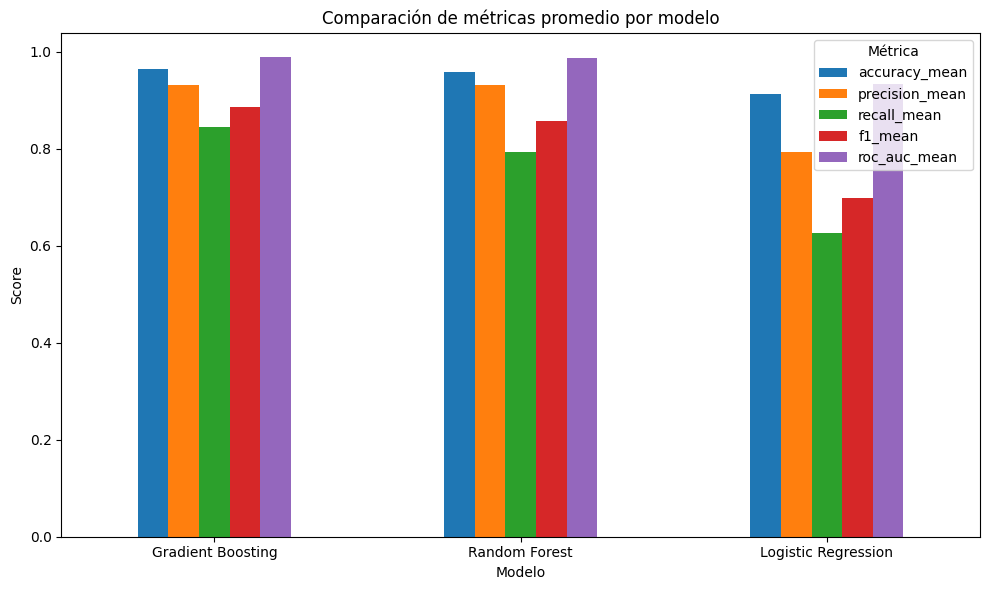

In [125]:
metrics_to_plot = [
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "roc_auc_mean",
]

plot_df = results_df.set_index("model")[metrics_to_plot]
plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de métricas promedio por modelo")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

## 7. Selección del mejor modelo

Con base en los resultados de validación cruzada, se seleccionó `GradientBoostingClassifier` como el mejor modelo base.

La decisión se tomó principalmente a partir del F1-score medio, ya que esta métrica balancea precision y recall y resulta más informativa que accuracy en un problema de churn con clases desbalanceadas.

Además, `GradientBoostingClassifier` obtuvo el mejor desempeño en recall, accuracy y ROC AUC, manteniendo un nivel de precision prácticamente igual al de `RandomForestClassifier`.

In [126]:
best_model_name = results_df.loc[0, "model"]
best_model_name

'Gradient Boosting'

In [127]:
best_model = GradientBoostingClassifier(random_state=42)

best_pipeline_base = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", best_model)]
)

best_pipeline_base

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 8. Tuning de hiperparámetros

Una vez identificado `GradientBoostingClassifier` como el mejor modelo base, se realiza una búsqueda de hiperparámetros para mejorar su desempeño.

Se utiliza `RandomizedSearchCV` en lugar de `GridSearchCV` para explorar un espacio relativamente amplio de configuraciones con un costo computacional más razonable.

La métrica principal de optimización es el F1-score, ya que en este problema interesa balancear precision y recall en la detección de churn.

In [128]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42)),
    ]
)

In [129]:
param_distributions = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 0.9, 1.0],
}

In [130]:
random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

In [131]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strateg

In [132]:
print("Mejor score CV (F1):", round(random_search.best_score_, 4))
print("Mejores hiperparámetros:")
random_search.best_params_

Mejor score CV (F1): 0.902
Mejores hiperparámetros:


{'model__subsample': 0.8,
 'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 4,
 'model__max_depth': 3,
 'model__learning_rate': 0.1}

In [133]:
best_pipeline_tuned = random_search.best_estimator_
best_pipeline_tuned

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [134]:
tuning_results = pd.DataFrame(random_search.cv_results_)

cols_to_show = [
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__subsample",
]

tuning_results = (
    tuning_results[cols_to_show]
    .sort_values(by="rank_test_score")
    .reset_index(drop=True)
)

tuning_results.head(10)

,mean_test_score,std_test_score,rank_test_score,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__subsample
0,0.901977,0.009947,1,200,0.10,3,2,4,0.8
1,0.899737,0.013574,2,300,0.03,4,5,2,0.9
2,0.898097,0.008191,3,300,0.10,2,5,2,0.8
3,0.894693,0.015478,4,150,0.10,3,5,2,0.8
4,0.894193,0.017931,5,150,0.05,4,10,4,0.9
5,0.884568,0.012438,6,200,0.10,2,2,4,0.8
6,0.880507,0.017315,7,300,0.03,3,2,2,0.9
7,0.876913,0.019671,8,300,0.03,3,2,2,1.0
8,0.870389,0.019621,9,100,0.05,4,10,1,1.0
9,0.866902,0.020564,10,150,0.03,4,5,4,0.9


El proceso de tuning permitió mejorar el desempeño del modelo base de Gradient Boosting.

El mejor modelo encontrado alcanzó un F1-score promedio de 0.9020 en validación cruzada, superior al obtenido por la versión base del modelo. Además, la desviación estándar fue baja, lo que sugiere un comportamiento relativamente estable entre folds.

En consecuencia, se seleccionó esta versión tuneada como modelo final candidato para la evaluación sobre el conjunto holdout.

In [135]:
base_f1 = results_df.loc[results_df["model"] == "Gradient Boosting", "f1_mean"].iloc[0]
tuned_f1 = random_search.best_score_

print(f"F1 modelo base   : {base_f1:.4f}")
print(f"F1 modelo tuneado: {tuned_f1:.4f}")
print(f"Mejora absoluta  : {tuned_f1 - base_f1:.4f}")

F1 modelo base   : 0.8858
F1 modelo tuneado: 0.9020
Mejora absoluta  : 0.0162


In [136]:
random_search.best_params_

{'model__subsample': 0.8,
 'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 4,
 'model__max_depth': 3,
 'model__learning_rate': 0.1}

## 9. Evaluación final en holdout

Una vez seleccionado y ajustado el mejor modelo, se evalúa su desempeño final sobre el conjunto holdout, que no participó ni en la comparación inicial de modelos ni en la búsqueda de hiperparámetros.

En esta sección se reportan:

- métricas de clasificación;
- matriz de confusión;
- curva ROC y AUC;
- curva Precision-Recall y Average Precision.

Esto permite medir de forma más realista la capacidad de generalización del pipeline final.

In [137]:
y_pred = best_pipeline_tuned.predict(X_test)
y_proba = best_pipeline_tuned.predict_proba(X_test)[:, 1]

In [138]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9696    0.9924    0.9808      1701
           1     0.9544    0.8369    0.8918       325

    accuracy                         0.9674      2026
   macro avg     0.9620    0.9146    0.9363      2026
weighted avg     0.9671    0.9674    0.9665      2026



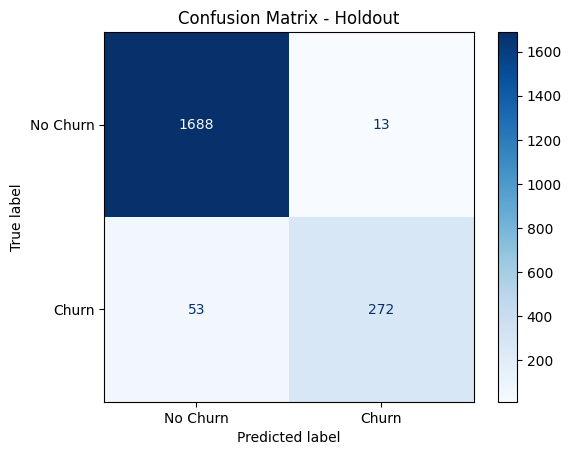

In [139]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Holdout")
plt.show()

In [140]:
holdout_metrics = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision",
        ],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_proba),
            average_precision_score(y_test, y_proba),
        ],
    }
)

holdout_metrics["value"] = holdout_metrics["value"].round(4)
holdout_metrics

,metric,value
0,accuracy,0.9674
1,precision,0.9544
2,recall,0.8369
3,f1,0.8918
4,roc_auc,0.9918
5,average_precision,0.9659


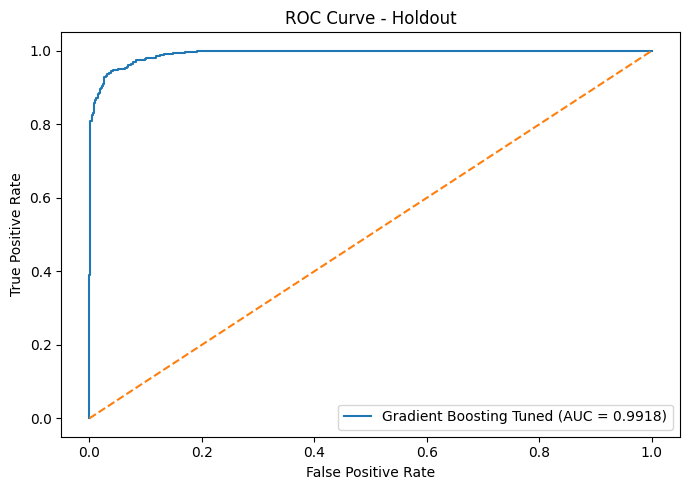

In [141]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting Tuned (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Holdout")
plt.legend()
plt.tight_layout()
plt.show()

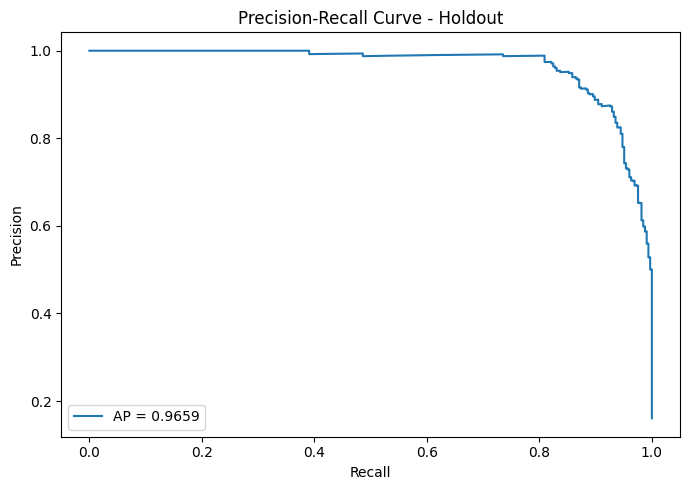

In [142]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Holdout")
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
best_pipeline_base.fit(X_train, y_train)

y_pred_base = best_pipeline_base.predict(X_test)
y_proba_base = best_pipeline_base.predict_proba(X_test)[:, 1]

comparison_holdout = pd.DataFrame(
    {
        "model": ["Gradient Boosting Base", "Gradient Boosting Tuned"],
        "accuracy": [
            accuracy_score(y_test, y_pred_base),
            accuracy_score(y_test, y_pred),
        ],
        "precision": [
            precision_score(y_test, y_pred_base),
            precision_score(y_test, y_pred),
        ],
        "recall": [
            recall_score(y_test, y_pred_base),
            recall_score(y_test, y_pred),
        ],
        "f1": [
            f1_score(y_test, y_pred_base),
            f1_score(y_test, y_pred),
        ],
        "roc_auc": [
            roc_auc_score(y_test, y_proba_base),
            roc_auc_score(y_test, y_proba),
        ],
    }
)

comparison_holdout = comparison_holdout.round(4)
comparison_holdout

,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting Base,0.9625,0.9560,0.8031,0.8729,0.9894
1,Gradient Boosting Tuned,0.9674,0.9544,0.8369,0.8918,0.9918


### Conclusión de la evaluación final

El modelo final tuneado de `GradientBoostingClassifier` mostró un desempeño sólido sobre el conjunto holdout, lo que sugiere una buena capacidad de generalización.

En comparación con la versión base, el modelo tuneado mejoró las métricas más relevantes para el problema de churn, especialmente `recall` y `f1`, manteniendo una `precision` muy alta. Esto indica que el ajuste de hiperparámetros permitió detectar una mayor proporción de clientes en riesgo de abandono sin incrementar de manera importante los falsos positivos.

La matriz de confusión confirma este resultado: el modelo clasificó correctamente 272 casos de churn y solo cometió 13 falsos positivos, mientras que la curva Precision-Recall y el valor de Average Precision (`0.9659`) respaldan una muy buena capacidad de separación entre ambas clases.

En consecuencia, el pipeline tuneado se selecciona como el modelo final de la parte clásica con scikit-learn.

## 10. Feature importance / interpretación

Para interpretar el modelo final, se extraen las importancias de variables del `GradientBoostingClassifier` ya entrenado dentro del pipeline.

Dado que el preprocesamiento incluye codificación one-hot para variables categóricas, las importancias se analizan sobre las variables transformadas resultantes.

Esto permite identificar qué atributos tienen mayor peso en la predicción de churn y aportar una primera capa de interpretabilidad al modelo.

In [144]:
# =========================
# 10. Feature importance / interpretación
# =========================

# Extraer nombres de variables transformadas
feature_names = best_pipeline_tuned.named_steps["preprocessor"].get_feature_names_out()

# Extraer importancias del modelo
importances = best_pipeline_tuned.named_steps["model"].feature_importances_

# Construir dataframe de importancias
feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

,feature,importance
0,num__Total_Trans_Ct,0.314560
1,num__Total_Revolving_Bal,0.185101
2,num__Total_Trans_Amt,0.168958
3,num__Total_Ct_Chng_Q4_Q1,0.097483
4,num__Total_Relationship_Count,0.084562
5,num__Avg_Trans_Amt,0.043093
6,num__Total_Amt_Chng_Q4_Q1,0.038886
7,num__Contacts_Count_12_mon,0.015977
8,num__Customer_Age,0.013989
9,num__Months_Inactive_12_mon,0.013715


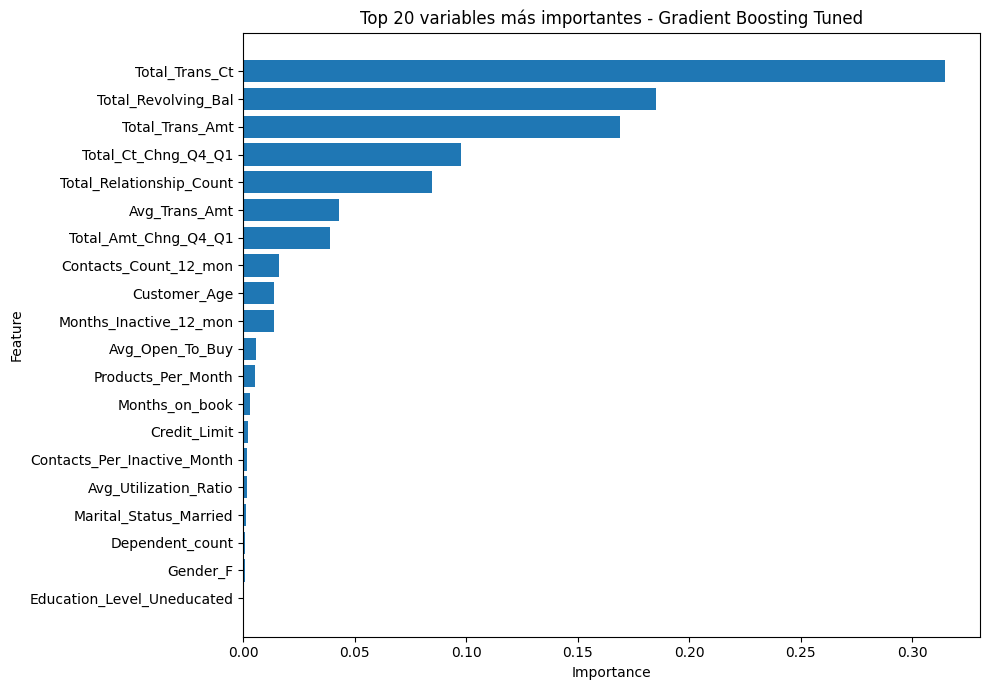

In [145]:
top_n = 20

feature_importance_df["feature_clean"] = (
    feature_importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_features = feature_importance_df.head(top_n).sort_values(
    "importance", ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature_clean"], top_features["importance"])
plt.title(f"Top {top_n} variables más importantes - Gradient Boosting Tuned")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Conclusión de interpretación

El análisis de importancia de variables muestra que el modelo final se apoya principalmente en atributos de comportamiento transaccional y relación con el cliente.

Las variables con mayor peso fueron `Total_Trans_Ct`, `Total_Revolving_Bal`, `Total_Trans_Amt`, `Total_Ct_Chng_Q4_Q1` y `Total_Relationship_Count`, lo que sugiere que la predicción de churn depende sobre todo de la **intensidad de uso de la tarjeta, los montos operados y los cambios recientes en la actividad del cliente**.

Además, algunas variables derivadas creadas en el EDA, como `Avg_Trans_Amt`, `Products_Per_Month` y `Contacts_Per_Inactive_Month`, también aportaron información al modelo, aunque en menor medida que las variables transaccionales principales.

En contraste, las variables demográficas y categóricas tuvieron una importancia relativamente baja, por lo que el modelo parece capturar mejor señales de comportamiento que de perfil estático del cliente.

## 11. Serialización del pipeline

Finalmente, se serializa el pipeline completo ya entrenado mediante `joblib.dump()`.

Guardar el pipeline completo —y no únicamente el modelo— permite reutilizar en inferencia exactamente el mismo flujo aplicado durante entrenamiento: imputación, escalado, codificación de variables categóricas y predicción.

Además, se realiza una verificación simple cargando nuevamente el artefacto serializado y comparando sus predicciones con las del pipeline original.

In [146]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "gradient_boosting_tuned_pipeline.joblib"

joblib.dump(best_pipeline_tuned, MODEL_PATH)

print(f"Pipeline guardado en: {MODEL_PATH}")

Pipeline guardado en: ../models/gradient_boosting_tuned_pipeline.joblib


In [147]:
loaded_pipeline = joblib.load(MODEL_PATH)

print("Pipeline cargado correctamente.")
loaded_pipeline

Pipeline cargado correctamente.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [148]:
# comprobación de predicciones
y_pred_loaded = loaded_pipeline.predict(X_test)
y_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]

In [149]:
import numpy as np

print("¿Predicciones de clase idénticas?:", np.array_equal(y_pred, y_pred_loaded))

¿Predicciones de clase idénticas?: True


In [150]:
print("¿Probabilidades prácticamente iguales?:", np.allclose(y_proba, y_proba_loaded))

¿Probabilidades prácticamente iguales?: True


In [151]:
verification_metrics = pd.DataFrame(
    {
        "metric": ["accuracy", "f1", "roc_auc"],
        "original_pipeline": [
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_proba),
        ],
        "loaded_pipeline": [
            accuracy_score(y_test, y_pred_loaded),
            f1_score(y_test, y_pred_loaded),
            roc_auc_score(y_test, y_proba_loaded),
        ],
    }
)

verification_metrics = verification_metrics.round(4)
verification_metrics

,metric,original_pipeline,loaded_pipeline
0,accuracy,0.9674,0.9674
1,f1,0.8918,0.8918
2,roc_auc,0.9918,0.9918


## 12. Conclusiones

En este notebook se construyó un pipeline clásico de machine learning para predecir churn de clientes de tarjeta de crédito utilizando `scikit-learn`.

Primero, se integró el preprocesamiento mediante `ColumnTransformer`, separando el tratamiento de variables numéricas y categóricas dentro de un flujo reproducible. Posteriormente, se compararon tres modelos de clasificación mediante validación cruzada estratificada: `LogisticRegression`, `RandomForestClassifier` y `GradientBoostingClassifier`.

Los resultados mostraron que `GradientBoostingClassifier` fue el mejor modelo base, por lo que se seleccionó para la etapa de tuning. La búsqueda de hiperparámetros con `RandomizedSearchCV` permitió mejorar el desempeño del modelo, especialmente en términos de `recall` y `f1-score`, manteniendo una `precision` alta.

La evaluación final sobre el conjunto holdout confirmó una buena capacidad de generalización del pipeline tuneado. Además, el análisis de importancia de variables mostró que las señales más relevantes provienen principalmente del comportamiento transaccional del cliente, como número de transacciones, saldo revolvente, monto transaccionado y cambios recientes en el uso de la tarjeta.

Finalmente, el pipeline completo fue serializado exitosamente con `joblib`, dejando listo un artefacto reutilizable para las siguientes etapas del proyecto, como validación con Pandera, tracking con MLflow o despliegue en Streamlit.